# 🌀 Diffusion Models: MNIST Generation Experiments

---



# 🧪 Experiment 1: Implementing and Training a Diffusion Model on MNIST


### 🔧 Step 1: Install Required Libraries

Make sure the following libraries are installed: `torch`, `torchvision`, `matplotlib`, and `tqdm`.

Use the cell below to install them.

In [ ]:
# Install any needed libraries
!pip install torch torchvision matplotlib tqdm --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.8 MB/s eta 0:00:00


In [ ]:
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import math




## 📥 Load the MNIST Dataset


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

mnist = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(mnist, batch_size=64, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 12.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.20MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.03MB/s]


### 🌫️ Step 2: Define the Noise Schedule

Implement a design beta noise schedule for a total of x number of timesteps. x is a design choice.

🧠 **Implementation:**
- Decide whether to use a **linear** beta schedule or a **cosine** schedule.
- Implement the schedule accordingly.
- Compute `alphas` and `alpha_hats` for the diffusion process.

> This is a design choice. Think about how each schedule might impact the training.


In [ ]:

timesteps = 1000

beta_start = 0.0001
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, timesteps)

alphas = 1. - betas
alpha_hats = torch.cumprod(alphas, dim=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
betas = betas.to(device)
alphas = alphas.to(device)
alpha_hats = alpha_hats.to(device)

### 💨 Step 3: Implement Forward Diffusion Function

Create a function `forward_diffusion_sample(x_0, t)` that:

- Adds noise to the input image `x_0` at a given timestep `t`.
- Returns both the noised image and the added noise.

Use the computed `alpha_hats` to scale the input and noise correctly.


In [ ]:
def forward_diffusion_sample(x_0, t):
    noise = torch.randn_like(x_0)

    t = t.to(device)

    sqrt_alpha_hat = torch.sqrt(alpha_hats[t])[:, None, None, None]
    sqrt_one_minus_alpha_hat = torch.sqrt(1 - alpha_hats[t])[:, None, None, None]

    x_t = sqrt_alpha_hat * x_0 + sqrt_one_minus_alpha_hat * noise

    return x_t, noise

### 👁️ Step 4: Visualize the Diffusion Process

Pick a sample image from the dataset and visualize how it looks after applying noise at different timesteps (e.g. t = 0, 50, 100, 150, 199, ... x)



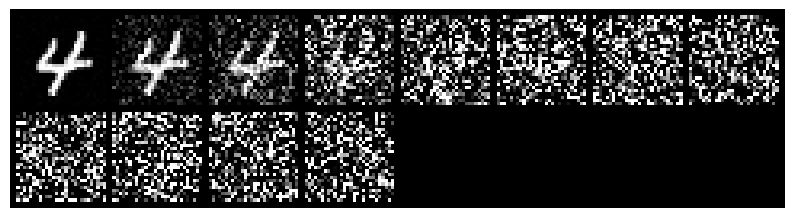

In [ ]:
# Visualize diffusion over timesteps
def show_image_grid(images):
    grid = make_grid(images, nrow=8)
    plt.figure(figsize=(10, 10))
    plt.imshow(grid.permute(1, 2, 0).cpu())
    plt.axis('off')
    plt.show()

# Show progression of one image
x, _ = next(iter(dataloader))
x = x[:1].to(device)  # Take just the first image and move to device

# Select timesteps to visualize
timesteps_to_show = [0, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 999]

noised_images = []
for t in timesteps_to_show:
    t_batch = torch.tensor([t], device=device)
    noised, _ = forward_diffusion_sample(x, t_batch)
    noised_images.append(noised)

show_image_grid(torch.cat(noised_images, dim=0))

### 🧠 Step 5: Build the Denoising Model

Implement a U-Net style architecture to predict noise given a noisy image and a timestep `t`.


In [ ]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2

        log_factor = math.log(10000) / (half_dim - 1)
        position_indices = torch.arange(half_dim, device=device)
        scaled_indices = position_indices * -log_factor
        frequency_factors = torch.exp(scaled_indices)

        expanded_time = time.unsqueeze(1)
        expanded_factors = frequency_factors.unsqueeze(0)
        position_encodings = expanded_time * expanded_factors

        sin_encodings = torch.sin(position_encodings)
        cos_encodings = torch.cos(position_encodings)

        embeddings = torch.cat((sin_encodings, cos_encodings), dim=-1)
        return embeddings


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, kernel_size=3):
        super().__init__()

        self.time_projection = nn.Linear(time_emb_dim, out_ch)

        padding_size = kernel_size // 2
        self.conv_layers = nn.ModuleList([
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=padding_size),
            nn.Conv2d(out_ch, out_ch, kernel_size=kernel_size, padding=padding_size)
        ])

        self.norm_layers = nn.ModuleList([
            nn.BatchNorm2d(out_ch),
            nn.BatchNorm2d(out_ch)
        ])

        self.residual_connection = (
            nn.Identity() if in_ch == out_ch
            else nn.Conv2d(in_ch, out_ch, kernel_size=1)
        )

    def forward(self, x, t):
        conv_output = self.conv_layers[0](x)
        activated_output = F.relu(conv_output)
        normalized_output = self.norm_layers[0](activated_output)

        time_embedding = self.time_projection(t)
        time_embedding = time_embedding.unsqueeze(2).unsqueeze(3)
        h = normalized_output + time_embedding

        conv_output2 = self.conv_layers[1](h)
        activated_output2 = F.relu(conv_output2)
        normalized_output2 = self.norm_layers[1](activated_output2)

        residual = self.residual_connection(x)
        output = normalized_output2 + residual

        return output


class UNet(nn.Module):
    def __init__(self, image_channels=1):
        super().__init__()
        self.time_dim = 128

        self.time_embedding = self._create_time_embedding()

        self.initial_projection = nn.Conv2d(image_channels, 64, kernel_size=3, padding=1)

        self.encoder = self._create_encoder()

        self.middle = Block(256, 512, self.time_dim, kernel_size=3)

        self.decoder = self._create_decoder()

        self.final_projection = nn.Conv2d(128, image_channels, kernel_size=1)

    def _create_time_embedding(self):
        return nn.Sequential(
            SinusoidalPositionEmbeddings(self.time_dim),
            nn.Linear(self.time_dim, self.time_dim),
            nn.ReLU()
        )

    def _create_encoder(self):
        return nn.ModuleDict({
            'down_block1': Block(64, 128, self.time_dim, kernel_size=3),
            'pooling1': nn.MaxPool2d(2),
            'down_block2': Block(128, 256, self.time_dim, kernel_size=3),
            'pooling2': nn.MaxPool2d(2)
        })

    def _create_decoder(self):
        return nn.ModuleDict({
            'upsampling1': nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2),
            'up_block1': Block(512, 256, self.time_dim, kernel_size=3),
            'upsampling2': nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2),
            'up_block2': Block(256, 128, self.time_dim, kernel_size=3)
        })

    def forward(self, x, t):
        time_features = self.time_embedding(t)

        x0 = self.initial_projection(x)

        skip_features = []

        x1 = self.encoder['down_block1'](x0, time_features)
        skip_features.append(x1)
        x = self.encoder['pooling1'](x1)

        x2 = self.encoder['down_block2'](x, time_features)
        skip_features.append(x2)
        x = self.encoder['pooling2'](x2)

        x = self.middle(x, time_features)

        x = self.decoder['upsampling1'](x)

        x = torch.cat([x, skip_features[1]], dim=1)
        x = self.decoder['up_block1'](x, time_features)


        x = self.decoder['upsampling2'](x)

        x = torch.cat([x, skip_features[0]], dim=1)
        x = self.decoder['up_block2'](x, time_features)

        return self.final_projection(x)

### 🏋️ Step 6: Train the Denoiser

- Instantiate the model and move it to the correct device (`cuda` if available).
- Define an optimizer (e.g., Adam) and a suitable learning rate.
- Write a training loop for the denoiser.

Show the loss at the end of each epoch.

Plot the loss curve

  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/10, Average Loss: 0.0509


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/10, Average Loss: 0.0233


  0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 8/10, Average Loss: 0.0167


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 9/10, Average Loss: 0.0166


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 10/10, Average Loss: 0.0163


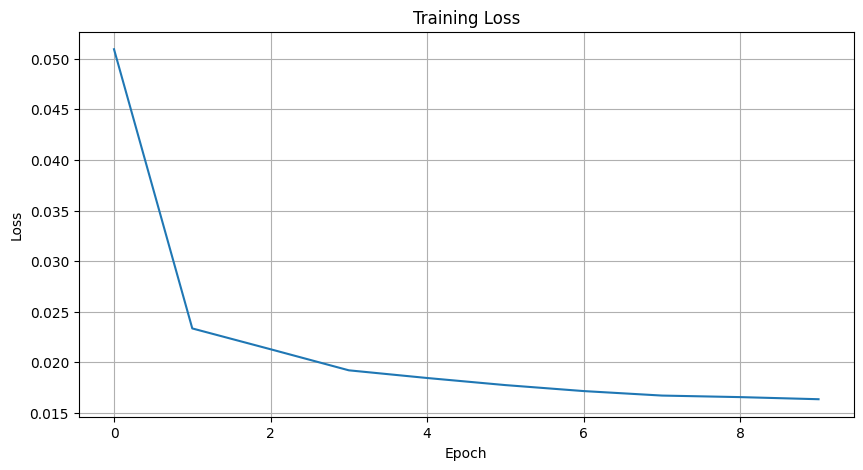

In [ ]:

model = UNet().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10
losses = []

criterion = nn.MSELoss()

for epoch in range(num_epochs):
    epoch_losses = []

    progress_bar = tqdm(dataloader)
    for step, (images, _) in enumerate(progress_bar):
        images = images.to(device)

        optimizer.zero_grad()

        t = torch.randint(0, timesteps, (images.shape[0],), device=device).long()

        x_t, noise = forward_diffusion_sample(images, t)

        predicted_noise = model(x_t, t)

        loss = criterion(predicted_noise, noise)

        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        progress_bar.set_description(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### ✨ Step 7: Generate a Sample by Reversing Diffusion

Plot the final denoised image.


Sampling: 0it [00:00, ?it/s]

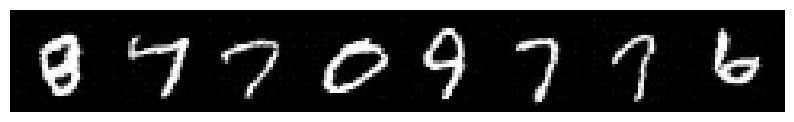

In [ ]:
@torch.no_grad()
def sample_from_model(model, image_size=28, batch_size=8):
    model.eval()

    img = torch.randn(batch_size, 1, image_size, image_size).to(device)

    for i in tqdm(reversed(range(0, timesteps)), desc='Sampling'):
        t = torch.full((batch_size,), i, device=device, dtype=torch.long)

        predicted_noise = model(img, t)

        alpha = alphas[t][:, None, None, None]
        alpha_hat = alpha_hats[t][:, None, None, None]
        beta = betas[t][:, None, None, None]

        if i > 0:
            noise = torch.randn_like(img)
        else:
            noise = torch.zeros_like(img)

        img = 1 / torch.sqrt(alpha) * (img - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * predicted_noise) + torch.sqrt(beta) * noise

    model.train()
    return img

samples = sample_from_model(model)
show_image_grid(samples)

## 🧠 Analytical Questions

Answer the following questions in a separate Markdown cell:

1. Prove that the forward process is a Markov chain. What assumptions are being made?
2. Derive the expression for the mean and variance of the noisy image at timestep \( t \).
3. How does the choice of the beta schedule affect the learning process and final image quality?
4. What would happen if we used too few timesteps (e.g., T = 20)?

Answers:
1. A Markov chain is a process where the future state depends only on the current state, not on the sequence of states that preceded it.
In diffusion models, the forward process can be described as:
q(x_t | x_{t-1}) = N(x_t; sqrt(1-Beta_t)x_{t-1}, Beta_t I)
This means x_t is conditionally dependent only on x_{t-1}, making it a Markov chain.

Assumptions:

        The noise added at each step is Gaussian.

        The noise variance Beta_t is fixed for each timestep.

        The process is time-homogeneous within each step.

        The noise added at each step is independent of the noise added at other steps.


2. Starting with x_0 (original image), we can derive x_t directly:
q(x_t | x_0) = N(x_t; sqrt(alpha_t)x_0, (1-alpha_t)I)
Where alpha_t = Product_{i=1}^t (1-Beta_i)
Mean: sqrt(alpha_t)x_0
Variance: (1-alpha_t)I
This is because we can combine multiple steps of Gaussian noise addition into a single Gaussian distribution with an adjusted mean and variance.


3. The beta schedule controls how quickly images get noised.
Linear schedule: Simple but may add too much noise too quickly at the beginning or too slowly at the end.
Cosine schedule: Provides a more balanced noise addition that preserves structure longer at early timesteps and adds more noise at later timesteps. This often results in better image quality and more stable training.


4. The "jumps" between noise levels would be too large

The model would struggle to learn smooth denoising

The forward process would add noise too abruptly, making the reverse process difficult

Generated samples would likely have poorer quality with artifacts

Training might become unstable


---
# 🧪 Experiment 2: Class-Conditional Diffusion on MNIST


### 🧠 Step 1: Define the Conditional Denoising Model

Next,  build a class-conditional version of your denoising U-Net from Experiment 1.

Requirements:
- Add a learnable **class embedding layer** (`nn.Embedding`) for MNIST digit classes (0–9).
- Concatenate the **time embedding** and **class embedding**.
- Use the combined embedding.




In [ ]:
class ConditionalUNet(nn.Module):
    def __init__(self, image_channels=1, num_classes=10):
        super().__init__()
        self.time_dim = 128
        self.class_dim = 128

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(self.time_dim),
            nn.Linear(self.time_dim, self.time_dim),
            nn.ReLU()
        )

        self.class_embedding = nn.Embedding(num_classes, self.class_dim)
        self.class_mlp = nn.Sequential(
            nn.Linear(self.class_dim, self.class_dim),
            nn.ReLU()
        )

        combined_dim = self.time_dim + self.class_dim

        self.conv0 = nn.Conv2d(image_channels, 64, kernel_size=3, padding=1)

        self.down1 = Block(64, 128, combined_dim, kernel_size=3)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = Block(128, 256, combined_dim, kernel_size=3)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = Block(256, 512, combined_dim, kernel_size=3)

        # dcoder
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_block1 = Block(512, 256, combined_dim, kernel_size=3)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_block2 = Block(256, 128, combined_dim, kernel_size=3)

        self.output = nn.Conv2d(128, image_channels, kernel_size=1)

    def forward(self, x, t, y):
        t_emb = self.time_mlp(t)
        c_emb = self.class_mlp(self.class_embedding(y))

        combined_emb = torch.cat([t_emb, c_emb], dim=1)

        x0 = self.conv0(x)

        x1 = self.down1(x0, combined_emb)
        x = self.pool1(x1)

        x2 = self.down2(x, combined_emb)
        x = self.pool2(x2)

        x = self.bottleneck(x, combined_emb)

        x = self.up1(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up_block1(x, combined_emb)

        x = self.up2(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up_block2(x, combined_emb)

        return self.output(x)

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim, kernel_size=3):
        super().__init__()
        self.emb_mlp = nn.Linear(emb_dim, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.bn2 = nn.BatchNorm2d(out_ch)

        if in_ch != out_ch:
            self.shortcut = nn.Conv2d(in_ch, out_ch, kernel_size=1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, emb):
        h = self.bn1(F.relu(self.conv1(x)))
        # Use the combined embedding
        emb_out = self.emb_mlp(emb)[:, :, None, None]
        h = h + emb_out
        h = self.bn2(F.relu(self.conv2(h)))
        return h + self.shortcut(x)

### 🏋️ Step 2: Train the Conditional Model

Write a training loop similar to Experiment 1, but now pass class labels (`y`) along with the timestep (`t`) to the model.

🔁 Everything else (e.g., noise sampling, loss calculation) remains the same as Experiment 1.


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/10, Average Loss: 0.0511


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/10, Average Loss: 0.0229


  0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 8/10, Average Loss: 0.0160


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 9/10, Average Loss: 0.0156


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 10/10, Average Loss: 0.0155


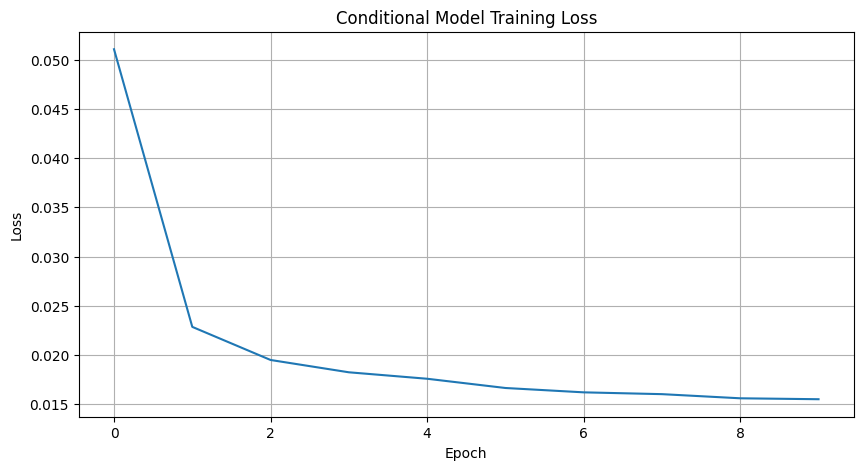

In [ ]:

cond_model = ConditionalUNet().to(device)

optimizer = torch.optim.Adam(cond_model.parameters(), lr=1e-4)

num_epochs = 10
losses = []

criterion = nn.MSELoss()

for epoch in range(num_epochs):
    epoch_losses = []

    progress_bar = tqdm(dataloader)
    for step, (images, labels) in enumerate(progress_bar):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        t = torch.randint(0, timesteps, (images.shape[0],), device=device).long()

        x_t, noise = forward_diffusion_sample(images, t)

        predicted_noise = cond_model(x_t, t, labels)

        loss = criterion(predicted_noise, noise)

        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())
        progress_bar.set_description(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")

    avg_loss = sum(epoch_losses) / len(epoch_losses)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title('Conditional Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

### ✨ Step 3: Sample Class-Conditioned Images

Write a sampling function to generate images conditioned on a class label.

🔁 Use the reverse diffusion process from Experiment 1.
- Only difference: now pass the label `y` to the model.


In [ ]:
@torch.no_grad()
def sample_from_model_conditional(model, class_labels, image_size=28):
    model.eval()

    batch_size = len(class_labels)
    class_labels = torch.tensor(class_labels, device=device)

    img = torch.randn(batch_size, 1, image_size, image_size).to(device)

    for i in tqdm(reversed(range(0, timesteps)), desc='Sampling'):
        t = torch.full((batch_size,), i, device=device, dtype=torch.long)

        predicted_noise = model(img, t, class_labels)

        alpha = alphas[t][:, None, None, None]
        alpha_hat = alpha_hats[t][:, None, None, None]
        beta = betas[t][:, None, None, None]

        if i > 0:
            noise = torch.randn_like(img)
        else:
            noise = torch.zeros_like(img)

        img = 1 / torch.sqrt(alpha) * (img - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * predicted_noise) + torch.sqrt(beta) * noise

    model.train()
    return img

### 🎨 Step 4: Visualize Class-Conditioned Samples

Generate and plot 1 image for each digit (0–9) using your class-conditional sampling function.
- Use `matplotlib` and display all results in a grid.
- Add titles showing the digit each image was conditioned on.


Sampling: 0it [00:00, ?it/s]

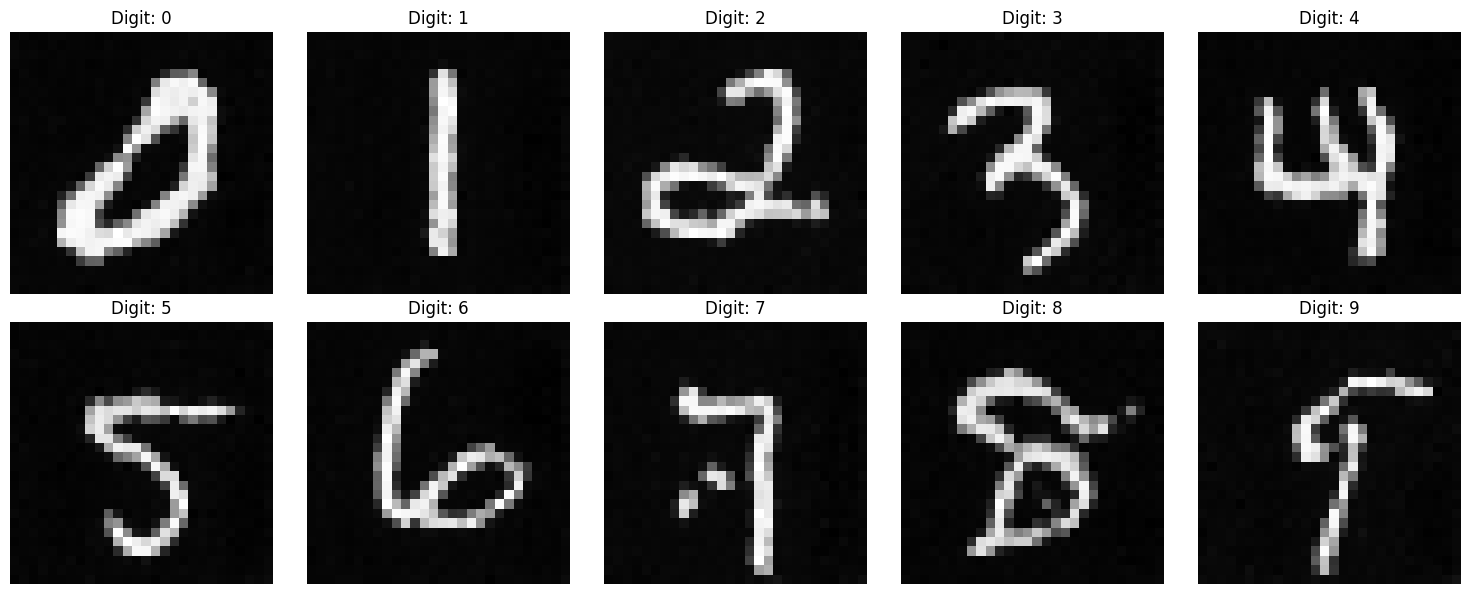

In [ ]:

class_labels = list(range(10))
samples = sample_from_model_conditional(cond_model, class_labels)

plt.figure(figsize=(15, 6))
for i, (img, label) in enumerate(zip(samples, class_labels)):
    plt.subplot(2, 5, i+1)
    plt.imshow(img.squeeze().cpu(), cmap='gray')
    plt.title(f"Digit: {label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

---
# 🧪 Experiment 3: Text-Guided Image Generation using CLIP + Diffusion

### 🔎 Step 1: Load a Pretrained CLIP Model

Use OpenAI’s CLIP model to obtain a text embedding from a given prompt.

🔍 Implementation:
- Find and install the CLIP library.
- Load a pretrained CLIP model of a design choice.
- Write a function to get normalized CLIP text embeddings from a prompt.

💡 Hint: Look into the `clip` module and `clip.tokenize`, `clip.load`, and `clip.encode_text`.


In [ ]:

!pip install git+https://github.com/openai/CLIP.git

import clip
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
clip_model, preprocess = clip.load('ViT-B/32', device=device)

def get_text_embedding(prompt):
    text_tokens = clip.tokenize([prompt]).to(device)
    with torch.no_grad():
        text_features = clip_model.encode_text(text_tokens)

    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    return text_features

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-6mnl69oh
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-6mnl69oh
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=b77e1c3371c8f948876395f527b2413363ff151a33b928ea8c3e07c767dd44d4
  Stored in directory: /tmp/pip-ephem-wheel-cache-nb82e3wz/wheels/3f/7c/a4/9b490845988bf7a4db33674d52f709f088f64392063872eb9a
Successfully built clip


100%|███████████████████████████████████████| 338M/338M [00:10<00:00, 33.8MiB/s]


### 🖼️ Step 2: Implement CLIP-Guided Loss

Create a function that:
- Resizes the generated image to 224x224.
- Converts it to 3 channels.
- Passes it through CLIP’s image encoder.
- Calculates the **cosine similarity** with the given text embedding.
- Returns the CLIP loss: `1 - cosine_similarity`.

📌 This loss will be used to guide your diffusion sampling.


In [ ]:
def clip_loss(image, text_embedding):
    batch_size = image.shape[0]

    image_rgb = image.repeat(1, 3, 1, 1)

    image_resized = F.interpolate(image_rgb, size=(224, 224), mode='bilinear')

    image_input = torch.clamp((image_resized + 1) / 2, 0, 1)

    with torch.no_grad():
        image_features = clip_model.encode_image(image_input)

    image_features = image_features / image_features.norm(dim=-1, keepdim=True)

    similarity = (image_features @ text_embedding.T).squeeze()

    return 1 - similarity

### 🔁 Step 3: Implement Text-Guided Sampling

Now generate an image **guided by a text prompt** using the reverse diffusion process.

🔧 Modify the DDPM sampling loop:
- At each step, predict noise using the model from experiment 1.
- Add a CLIP-guided loss term.
- Backpropagate through the generated image and adjust it with the CLIP gradient.

🧠 Use the diffusion schedule (`alpha`, `alpha_hat`, `beta`) from previous experiments.


In [ ]:
def text_guided_sample(prompt, diffusion_model, guidance_scale=100, num_steps=50):
    diffusion_model.eval()

    text_emb = get_text_embedding(prompt)

    x = torch.randn(1, 1, 28, 28).to(device)
    x.requires_grad = True

    img_optimizer = torch.optim.Adam([x], lr=0.01)

    sample_steps = min(timesteps, 1000)
    step_size = timesteps // sample_steps

    for i in tqdm(reversed(range(0, timesteps, step_size)), desc=f'Generating "{prompt}"'):
        t = torch.full((1,), i, device=device, dtype=torch.long)

        img_optimizer.zero_grad()

        with torch.enable_grad():
            noise_pred = diffusion_model(x, t)

            alpha = alphas[t][:, None, None, None]
            alpha_hat = alpha_hats[t][:, None, None, None]
            beta = betas[t][:, None, None, None]

            x_0_pred = (x - torch.sqrt(1 - alpha_hat) * noise_pred) / torch.sqrt(alpha_hat)
            x_0_pred = torch.clamp(x_0_pred, -1, 1)

            x_0_rgb = x_0_pred.repeat(1, 3, 1, 1)

            x_0_resized = F.interpolate(x_0_rgb, size=(224, 224), mode='bilinear')

            x_0_clip = torch.clamp((x_0_resized + 1) / 2, 0, 1)

            image_features = clip_model.encode_image(x_0_clip)

            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            similarity = (image_features @ text_emb.T).squeeze()
            c_loss = 1 - similarity

            loss = c_loss * guidance_scale

            loss.backward()
            img_optimizer.step()

        with torch.no_grad():
            noise_pred = diffusion_model(x, t)

            if i > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)

            x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * noise_pred) + torch.sqrt(beta) * noise

    diffusion_model.train()
    return x.detach()

### 🎯 Step 4: Generate Images from Prompts

Generate one image each for the following prompts:

- `"two"`
- `"five"`
- `"nine"`

Use the `text_guided_sample` function and visualize the results using `matplotlib`.

🎨 Title each image with the prompt used.


Generating "two": 0it [00:00, ?it/s]

Generating "five": 0it [00:00, ?it/s]

Generating "nine": 0it [00:00, ?it/s]

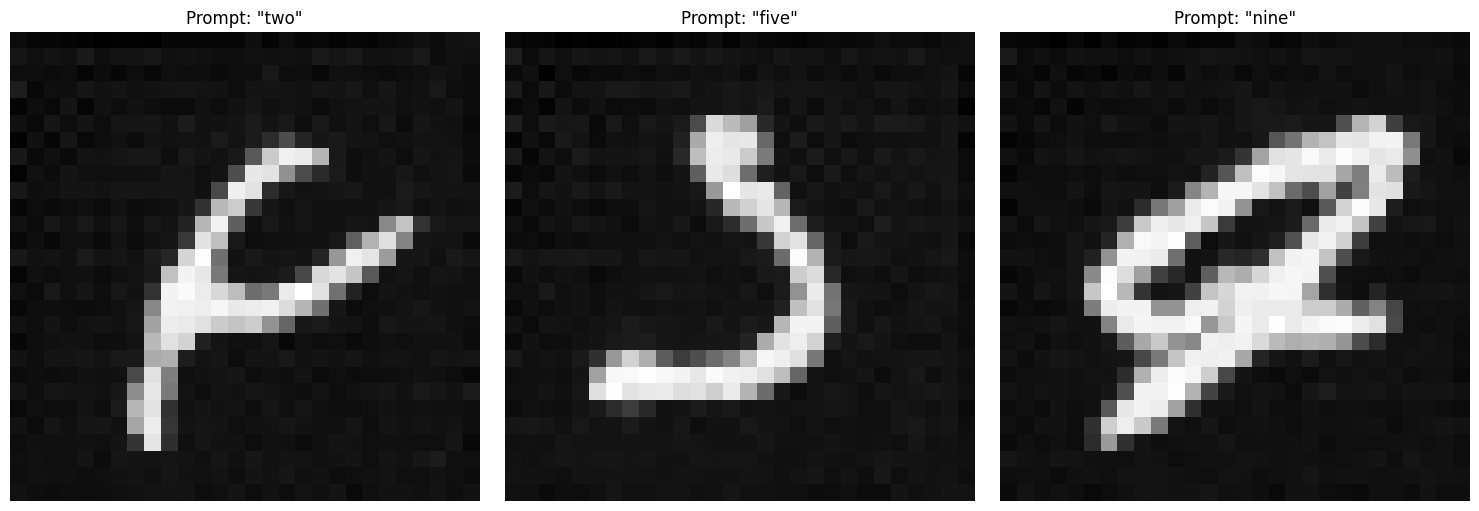

In [ ]:
prompts = ["two","five","nine"]

generated_images = []
for prompt in prompts:
    image = text_guided_sample(prompt, model, guidance_scale=100)
    generated_images.append(image)

plt.figure(figsize=(15, 5))
for i, (img, prompt) in enumerate(zip(generated_images, prompts)):
    plt.subplot(1, 3, i+1)
    plt.imshow(img.squeeze().cpu(), cmap='gray')
    plt.title(f'Prompt: "{prompt}"')
    plt.axis('off')
plt.tight_layout()
plt.show()


### 🔍 Questions

1. Do the outputs look like the digits you prompted?
2. How sensitive is the model to different wording (e.g., "number two" vs. "two")?
3. What would happen if you guide the image with a totally unrelated prompt (e.g., "dog")?




1. The prompt for two looks weird, but five and nine are very similar to the digits i prompted.

2. the model can be sensitive to exact wording. For example, 'number two'
   versus 'two' might produce slightly different results because CLIP's text encoder captures semantic nuances

3. The model might try to capture the form of a dog but since CLIP is trained on mnist, it would output the number with the closest shape to a dog, or just gibberish.